--- [단계 1] 데이터 수집 중 ---
총 50개의 데이터가 수집되었습니다.

--- [단계 2] 이미지 다운로드 중 ---
이미지 다운로드 완료.

--- [단계 3] 시각화 중 ---


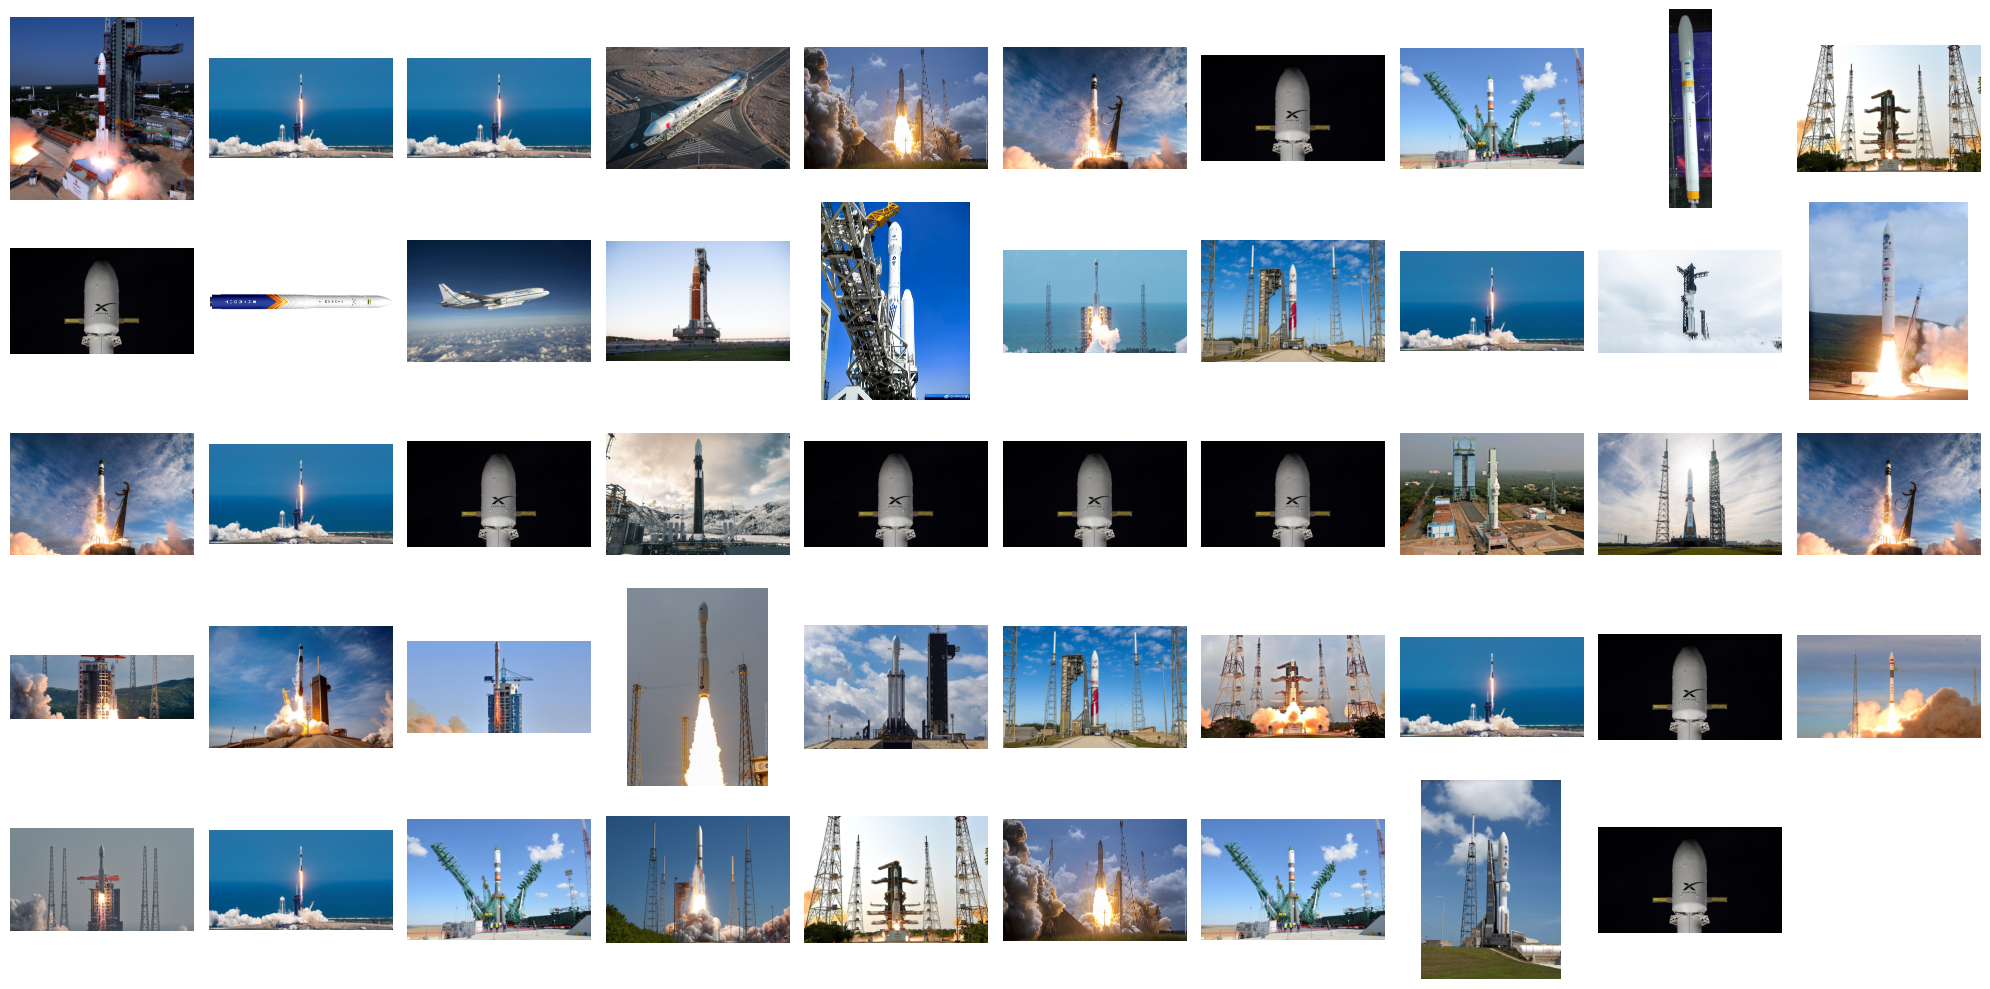

시각화 완료!


In [1]:
# 필요한 라이브러리 임포트
import requests
import pandas as pd
import os
import json
import time
from PIL import Image
import matplotlib.pyplot as plt

# 1. 데이터 수집 (Extract & Load JSON)
print("--- [단계 1] 데이터 수집 중 ---")
url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming/?limit=50"
response = requests.get(url)
data = response.json()

# 디렉토리 생성
os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)

# JSON 저장
with open("data/launches.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=4)

# 데이터프레임 확인
df = pd.DataFrame(data.get("results", []))
print(f"총 {len(df)}개의 데이터가 수집되었습니다.")

# 2. 이미지 추출 및 다운로드 (Transform & Download)
print("\n--- [단계 2] 이미지 다운로드 중 ---")
for i, row in df.iterrows():
    img_url = row.get("image")
    if img_url:
        try:
            img_data = requests.get(img_url, timeout=5).content
            file_path = f"images/launch_{i}.jpg"
            with open(file_path, "wb") as f:
                f.write(img_data)
        except:
            continue
print("이미지 다운로드 완료.")

# 3. 시각화 (Visualize)
print("\n--- [단계 3] 시각화 중 ---")
# 파일 목록 가져오기
image_files = [f for f in os.listdir("images") if f.endswith(".jpg")]

# 50개를 5행 10열로 시각화
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
axes = axes.flatten()

for i in range(50):
    if i < len(image_files):
        img_path = f"images/{image_files[i]}"
        img = Image.open(img_path)
        axes[i].imshow(img)
    axes[i].axis('off') # 축 제거

plt.tight_layout()
plt.show()
print("시각화 완료!")

--- [단계 1] Scikit-learn에서 데이터 추출 ---
데이터 추출 완료! 상위 5개 행:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- [단계 2] 데이터 변환 중 ---
결측치 개수:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
가격이 높은 주택 수: 1744건

--- [단계 3] 데이터 시각화 ---


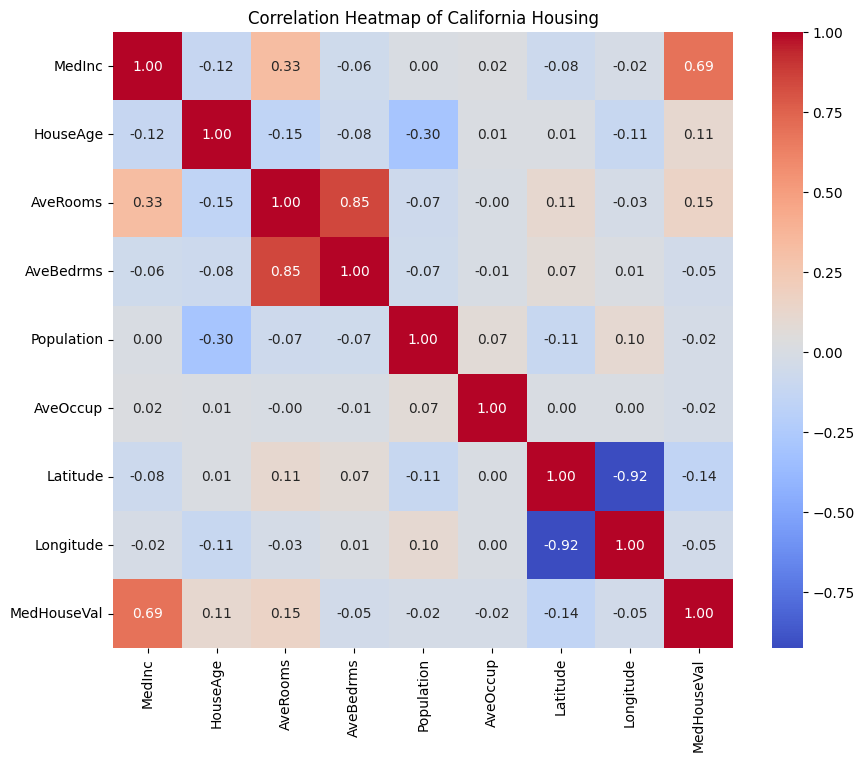

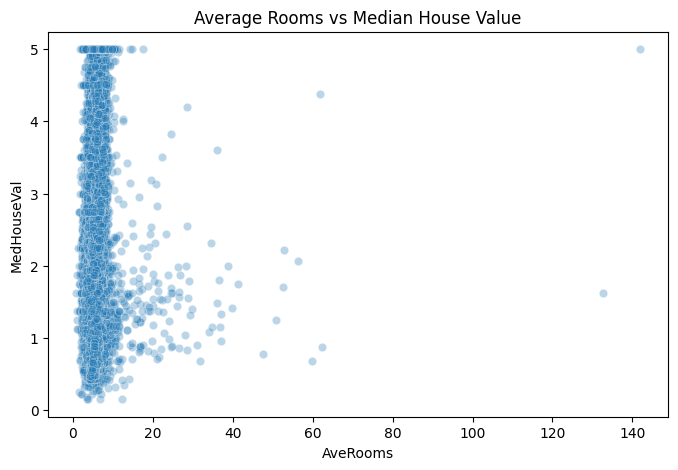


분석 완료: 'california_housing_cleaned.csv' 파일로 저장되었습니다.


In [2]:
# 1. 라이브러리 임포트
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# --- 단계 1: Extract (데이터 추출) ---
print("--- [단계 1] Scikit-learn에서 데이터 추출 ---")
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame
print("데이터 추출 완료! 상위 5개 행:")
print(df.head())

# --- 단계 2: Transform (데이터 변환 및 정제) ---
print("\n--- [단계 2] 데이터 변환 중 ---")
# 결측치 확인 (Scikit-learn 데이터는 정제가 잘 되어있으나 습관적으로 확인)
missing_values = df.isnull().sum()
print(f"결측치 개수:\n{missing_values}")

# 주택 가격(MedHouseVal)이 특정 값 이상인 데이터 필터링 예시
# 예: 중간 가격이 4.0 이상인 데이터만 추출
high_price_df = df[df['MedHouseVal'] > 4.0]
print(f"가격이 높은 주택 수: {len(high_price_df)}건")

# --- 단계 3: Load & Visualize (적재 및 시각화) ---
print("\n--- [단계 3] 데이터 시각화 ---")

# 상관관계 히트맵 (어떤 요인이 집값에 가장 큰 영향을 미치는지 확인)
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of California Housing')
plt.show()

# 특정 변수(예: 방 개수 vs 집값) 시각화
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='AveRooms', y='MedHouseVal', alpha=0.3)
plt.title('Average Rooms vs Median House Value')
plt.show()

# 분석된 결과 저장 (CSV로 Load)
df.to_csv("california_housing_cleaned.csv", index=False)
print("\n분석 완료: 'california_housing_cleaned.csv' 파일로 저장되었습니다.")